# Students 

Num| Name | Student ID |
|:---: | :---: | :---: |
1| عبدالله الهندي | 445002129 |
2| خالد الدمح | 44411552 |


## SODA Challenge 

SODA Challenge (Saudi Organic Dates Classification)!

This challenge invites the college of computing students to develop innovative models to accurately classify different varieties of Saudi organic dates based on image data.
This is a multi-class image classification task. Participants must build a model that predicts the correct date variety (label) for each image in the test set.


<img src="SODA.jpg">


### Importing libraries and extracting the data zip file

In [3]:
import shutil
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

#unzip the archive
if os.path.exists('data'):
    print('data directory already exists, skipping unzip')
    pass
else:
    shutil.unpack_archive('soda-challenge.zip', 'data')

(null): No such file or directory


data directory already exists, skipping unzip


#### *Initial Folder Structure*

 
``` bash
Soda_dataset 
    ├── images  
    │   ├── test  
    │   └── train  
    ├── sample_submission.csv  
    ├── test.csv  
    └── train.csv  
```


### EDA (Exploratory Data Analysis)

Plotting 4 random training images...


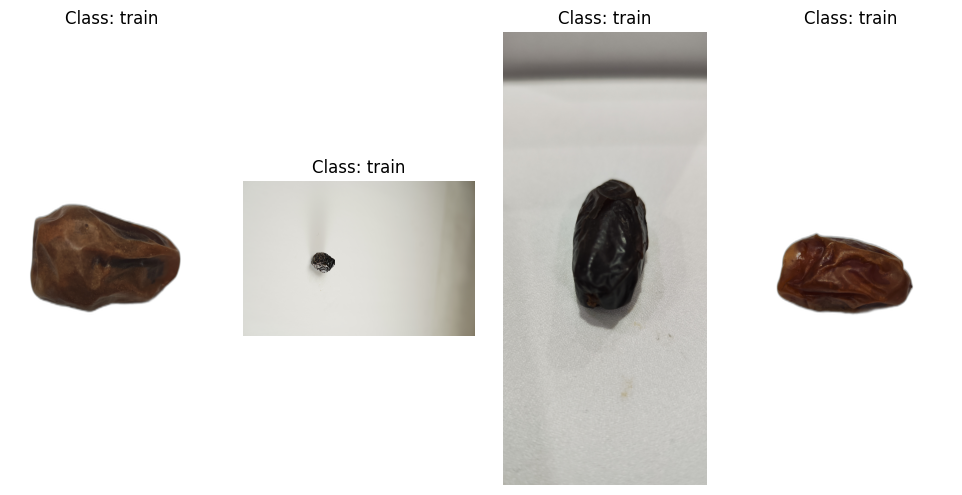

In [ ]:
#Display 4 random images from the training set

import random

#data path:
data_path = 'data/soda_dataset/images/train'



# Get all image paths from the training folder
all_image_paths = list(Path(data_path).glob('*'))
# Pick exactly 4 RANDOM images from the list
random_sample_paths = random.sample(all_image_paths, 4)

# Setup a clean grid with 1 row and 4 columns
fig, axes = plt.subplots(1, 4, figsize=(10, 5))
print("Plotting 4 random training images...")
for i, img_path in enumerate(random_sample_paths):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"Class: {img_path.parent.name}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

#### Get Class Distribution

--------------------------------------------------
Training set shape: (1829, 2)

<class 'pandas.DataFrame'>
RangeIndex: 1829 entries, 0 to 1828
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      1829 non-null   int64
 1   label   1829 non-null   int64
dtypes: int64(2)
memory usage: 28.7 KB
--------------------------------------------------
Test set shape: (784, 1) 

<class 'pandas.DataFrame'>
RangeIndex: 784 entries, 0 to 783
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      784 non-null    int64
dtypes: int64(1)
memory usage: 6.3 KB


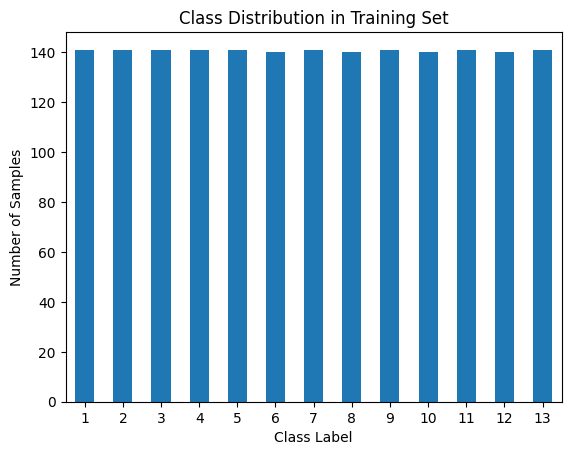

In [4]:
#load the csv file
train_df = pd.read_csv('data/soda_dataset/train.csv')
test_df = pd.read_csv('data/soda_dataset/test.csv')

print('-'*50)
print('Training set shape:', train_df.shape)
print('')
train_df.info()


print('-'*50)
print('Test set shape:', test_df.shape ,'\n')
test_df.info()

# Get class distribution
class_counts = train_df['label'].value_counts()
class_counts = class_counts.sort_index()  # Sort by class label


class_counts.plot(kind='bar')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Training Set')
plt.xticks(rotation=0)
plt.show()


| label | description |
| :--- | :--- |
| 1 | عجوة \| Ajwa |
| 2 | ونان Wannan |
| 3 | سكري جالكسي Sukari Galaxy |
| 4 | رزيز Raziz |
| 5 | خلاص Khalas |
| 6 | مجدول Medjool |
| 7 | سكري رطب Sukari Rutab |
| 8 | سكري مفتل Sukari Mofattal |
| 9 | شلبي Shalabi |
| 10 | شيشي Shaishi |
| 11 | صفاوي Safawi |
| 12 | صقعي Sagai |
| 13 | عنبرة Anbara |

#### prepare the data (Create a subfolder for each class seperatly)

In [7]:
#split the data based on the classes and store them in separate folders (train and test)
#we have 13 classes in total:
# | label | description |
# | :--- | :--- |
# | 1 | عجوة \| Ajwa |
# | 2 | ونان Wannan |
# | 3 | سكري جالكسي Sukari Galaxy |
# | 4 | رزيز Raziz |
# | 5 | خلاص Khalas |
# | 6 | مجدول Medjool |
# | 7 | سكري رطب Sukari Rutab |
# | 8 | سكري مفتل Sukari Mofattal |
# | 9 | شلبي Shalabi |
# | 10 | شيشي Shaishi |
# | 11 | صفاوي Safawi |
# | 12 | صقعي Sagai |
# | 13 | عنبرة Anbara |

# we have a train and a test folder, we will split the data in each folder based on the classes and store them in separate folders
# we will create a folder for each class in the train and test folders and move the images to the corresponding folders

# define the path to the train and test folders
train_path = 'data/train'
test_path = 'data/test'

# the classes are in the csv files, we will read the csv files and get the class labels
import pandas as pd

# read the csv files
train_csv = pd.read_csv('data/soda_dataset/train.csv')
test_csv = pd.read_csv('data/soda_dataset/test.csv')

# get the class labels
train_labels = train_csv['label'].unique()

# sorted the labels in ascending order
train_labels = sorted(int(label) for label in train_labels)

# Test labels are not provided in the test.csv file, we will use the train labels as test labels
test_labels = train_labels

print('Train labels:', train_labels)
print('Test labels:', test_labels)

# map the labels to the class names (English names)
label_to_class = {
    1: 'Ajwa',
    2: 'Wannan',
    3: 'Sukari Galaxy',
    4: 'Raziz',
    5: 'Khalas',
    6: 'Medjool',
    7: 'Sukari Rutab',
    8: 'Sukari Mofattal',
    9: 'Shalabi',
    10: 'Shaishi',
    11: 'Safawi',
    12: 'Sagai',
    13: 'Anbara'
}

# print the label to class mapping (each class in a  different line)
print('-'*50)
print('Label to class mapping:')
for label, class_name in label_to_class.items():
    print(f'{label}: {class_name}')


Train labels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Test labels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
--------------------------------------------------
Label to class mapping:
1: Ajwa
2: Wannan
3: Sukari Galaxy
4: Raziz
5: Khalas
6: Medjool
7: Sukari Rutab
8: Sukari Mofattal
9: Shalabi
10: Shaishi
11: Safawi
12: Sagai
13: Anbara


In [8]:
! rm -r data/train
! rm -r data/test

In [9]:
import os
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# --- STEP SUMMARY ---
print("=" * 60)
print("DATASET PREPARATION SUMMARY")
print("=" * 60)
print("1. Split training dataframe into Train (80%) and Validation (20%) sets.")
print("2. Create structured directories for YOLO/CNN classification:")
print("   - data/train/<ClassName>/")
print("   - data/val/<ClassName>/")
print("3. Copy training and validation images into their respective class folders.")
print("4. Copy all raw test images directly to 'data/test/' for final inference.")
print("5. Handle multiple extensions (.jpg, .jpeg, .png) dynamically.")
print("=" * 60)

# Define path configurations
base_img_dir = Path('data/soda_dataset/images')
output_train_dir = Path('data/train')
output_val_dir = Path('data/val')
output_test_dir = Path('data/test')

# Ensure core root directories exist
output_train_dir.mkdir(parents=True, exist_ok=True)
output_val_dir.mkdir(parents=True, exist_ok=True)
output_test_dir.mkdir(parents=True, exist_ok=True)

# Create class subfolders for both train and validation splits
for class_name in label_to_class.values():
    (output_train_dir / class_name).mkdir(parents=True, exist_ok=True)
    (output_val_dir / class_name).mkdir(parents=True, exist_ok=True)

# Stratified split: 80% train, 20% validation based on labels
train_df_split, val_df_split = train_test_split(
    train_df, 
    test_size=0.2, 
    stratify=train_df['label'], 
    random_state=42
)

# Helper function to scan for matching image extensions
def find_image_path(base_folder, image_id):
    extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
    for ext in extensions:
        potential_path = base_folder / f"{image_id}{ext}"
        if potential_path.exists():
            return potential_path
    return None

# --- 1. PROCESS TRAINING IMAGES ---
print("\n[1/3] Copying training split images...")
missing_train_images = 0

for idx, row in tqdm(train_df_split.iterrows(), total=len(train_df_split), desc="Train Split"):
    img_id = row['id']
    label_id = row['label']
    class_name = label_to_class[label_id]
    
    src_path = find_image_path(base_img_dir / 'train', img_id)
    if src_path:
        dest_path = output_train_dir / class_name / src_path.name
        shutil.copy(src_path, dest_path)
    else:
        missing_train_images += 1

print(f"-> Train copy finished. Missing files: {missing_train_images}")

# --- 2. PROCESS VALIDATION IMAGES ---
print("\n[2/3] Copying validation split images...")
missing_val_images = 0

for idx, row in tqdm(val_df_split.iterrows(), total=len(val_df_split), desc="Val Split"):
    img_id = row['id']
    label_id = row['label']
    class_name = label_to_class[label_id]
    
    src_path = find_image_path(base_img_dir / 'train', img_id)
    if src_path:
        dest_path = output_val_dir / class_name / src_path.name
        shutil.copy(src_path, dest_path)
    else:
        missing_val_images += 1

print(f"-> Val copy finished. Missing files: {missing_val_images}")

# --- 3. PROCESS TEST IMAGES ---
print("\n[3/3] Copying raw test images directly to target folder...")
missing_test_images = 0

for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Test Set"):
    img_id = row['id']
    
    src_path = find_image_path(base_img_dir / 'test', img_id)
    if src_path:
        dest_path = output_test_dir / src_path.name
        shutil.copy(src_path, dest_path)
    else:
        missing_test_images += 1

print(f"-> Test copy finished. Missing files: {missing_test_images}")
print("\n" + "=" * 60)
print("DATASET PROCESSING SUCCESSFULLY COMPLETED!")
print("=" * 60)

DATASET PREPARATION SUMMARY
1. Split training dataframe into Train (80%) and Validation (20%) sets.
2. Create structured directories for YOLO/CNN classification:
   - data/train/<ClassName>/
   - data/val/<ClassName>/
3. Copy training and validation images into their respective class folders.
4. Copy all raw test images directly to 'data/test/' for final inference.
5. Handle multiple extensions (.jpg, .jpeg, .png) dynamically.

[1/3] Copying training split images...


Train Split:   0%|          | 0/1463 [00:00<?, ?it/s]

Train Split: 100%|██████████| 1463/1463 [00:06<00:00, 229.26it/s]


-> Train copy finished. Missing files: 0

[2/3] Copying validation split images...


Val Split: 100%|██████████| 366/366 [00:01<00:00, 223.64it/s]


-> Val copy finished. Missing files: 0

[3/3] Copying raw test images directly to target folder...


Test Set: 100%|██████████| 784/784 [00:03<00:00, 212.26it/s]

-> Test copy finished. Missing files: 0

DATASET PROCESSING SUCCESSFULLY COMPLETED!


In [ ]:
# print the number of images in each class folder in the train and test folders

print('='*60)

print("\nNumber of images in each class folder (Train):")
for class_name in label_to_class.values():
    class_folder = output_train_dir / class_name
    if class_folder.exists():
        num_images = len(list(class_folder.glob('*.*')))  # Count all files in the class folder
        print(f"{class_name}: {num_images} images")

print('='*60)
print("\nNumber of images in each class folder (Validation):")
for class_name in label_to_class.values():
    class_folder = output_val_dir / class_name
    if class_folder.exists():
        num_images = len(list(class_folder.glob('*.*')))  # Count all files in the class folder
        print(f"{class_name}: {num_images} images")

print('='*60)
print("\nNumber of images in the test folder:")
num_test_images = len(list(output_test_dir.glob('*.*')))  # Count all files in the test folder
print(f"Test folder: {num_test_images} images")

total_train_images = sum(len(list((output_train_dir / class_name).glob('*.*'))) for class_name in label_to_class.values())
print(f"\nTotal training images: {total_train_images}")



Number of images in each class folder (Train):
Ajwa: 113 images
Wannan: 113 images
Sukari Galaxy: 113 images
Raziz: 113 images
Khalas: 112 images
Medjool: 112 images
Sukari Rutab: 113 images
Sukari Mofattal: 112 images
Shalabi: 113 images
Shaishi: 112 images
Safawi: 112 images
Sagai: 112 images
Anbara: 113 images

Number of images in each class folder (Validation):
Ajwa: 28 images
Wannan: 28 images
Sukari Galaxy: 28 images
Raziz: 28 images
Khalas: 29 images
Medjool: 28 images
Sukari Rutab: 28 images
Sukari Mofattal: 28 images
Shalabi: 28 images
Shaishi: 28 images
Safawi: 29 images
Sagai: 28 images
Anbara: 28 images

Number of images in the test folder:
Test folder: 784 images

Total training images: 1463


**Folder Structure (after splitting)**

```bash
data/
├── train/
│   ├── Ajwa/      <- Class folder (80% allocation)
│   └── ...        <- Total 13 class structures
├── val/
│   ├── Ajwa/      <- Class folder (20% validation split)
│   └── ...        <- Total 13 class structures
└── test/
    ├── 1.jpg      <- Flat image structure for simple batch submission loop
    ├── 2.png
    └── ...
```

In [10]:
# copy the train and validation folders to a new folder called data/yolo_dataset to be used for training the yolo model
yolo_dataset_dir = Path('data/yolo_dataset')

#if path and folders exist already in yolo_dataset, we will skip the copying process to avoid overwriting any existing data
if yolo_dataset_dir.exists():
    print("\n'yolo_dataset' directory already exists. Skipping copy to avoid overwriting existing data.")

    #remove the existing train, val, and test folders in the yolo_dataset directory to avoid any confusion
    #but don't remove the yolo_dataset nor the parent folder (data) to avoid any issues with the existing data
    shutil.rmtree('data/train')
    shutil.rmtree('data/val')
    shutil.rmtree('data/test')
    
else:
    yolo_train_dir = yolo_dataset_dir / 'train'
    yolo_val_dir = yolo_dataset_dir / 'val'
    yolo_test_dir = yolo_dataset_dir / 'test'

    # Create the yolo_dataset directory and its subdirectories
    yolo_train_dir.mkdir(parents=True, exist_ok=True)
    yolo_val_dir.mkdir(parents=True, exist_ok=True)
    yolo_test_dir.mkdir(parents=True, exist_ok=True)

    # Copy the train and validation folders to the yolo_dataset directory
    shutil.copytree(output_train_dir, yolo_train_dir, dirs_exist_ok=True)
    shutil.copytree(output_val_dir, yolo_val_dir, dirs_exist_ok=True)
    shutil.copytree(output_test_dir, yolo_test_dir, dirs_exist_ok=True)
    print("\nData preparation for YOLO training completed. Structured dataset is ready at 'data/yolo_dataset/'")


'yolo_dataset' directory already exists. Skipping copy to avoid overwriting existing data.


**Folder Structure after preperation for YOLO Training**

``` bash
data
└── yolo_dataset
    ├── train
    ├── val
    └── test
```

### Start Training the YOLO Classification model
#### Why YOLO26-cls?

Normally people think YOLO is only for object detection (finding bounding boxes), but using it for simple image classification actually make a lot of sense for our date fruit project. 

ESPECIALLY WITH NMS free Infrence

**Here is why we use it:** 

    - Super Fast: YOLO classification backbones are incredibly fast. It is heavily optimized to run on low-power devices, mobile phones, or edge cameras with almost zero delay.  

    - Insane simple API: We don't need to write 100 lines of complex PyTorch code just to build custom datasets loaders, training loops, or validation steps. Ultralytics handles everything in like 3 lines of code.  

    - No data.yaml needed: Unlike object detection, YOLO classification automatically map our folder names (Ajwa, Wannan, etc) directly into class labels.  

    - Focus on the object: Because YOLO architectures are fundamentally designed to find objects, its internal features are very good at ignoring background noise and focusing strictly on the fine details of the date fruit itself.  


<img src="YOLO26_Architecture.png" alt="Refrence: https://arxiv.org/pdf/2602.14582 ">


In [ ]:
# Check for GPU availability (ROCm/CUDA)
# For Local Training

import torch
print("ROCm / CUDA Available:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

ROCm / CUDA Available: True
Device Name: AMD Radeon Graphics


In [ ]:
from ultralytics import YOLO

# 1. Load a pretrained YOLO classification model 
# 'n' stands for nano (fastest, lightweight). You can use 's' (small) or 'm' (medium) if needed.
model = YOLO('yolo26s-cls.pt') 

# 2. Start training
results = model.train(
    data='data/yolo_dataset',    # Path to dataset folder containing train/ and val/
    epochs=50,                  # Number of training epochs
    imgsz=224,                  # Input image size (standard for classification)
    batch=32,                   # Batch size (adjust based on GPU memory)
    workers=12,                  # Number of CPU workers for loading data
    device=0,                   # Set to 0 for GPU, or 'cpu' if no GPU is available
    project='date_classification', # Parent directory for saved runs
    name='yolo_date_model'      # Specific folder name for this run
)

Ultralytics 8.4.58 🚀 Python-3.11.9 torch-2.12.0+rocm7.2 CUDA:0 (AMD Radeon Graphics, 16304MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_date_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

#### Training Result

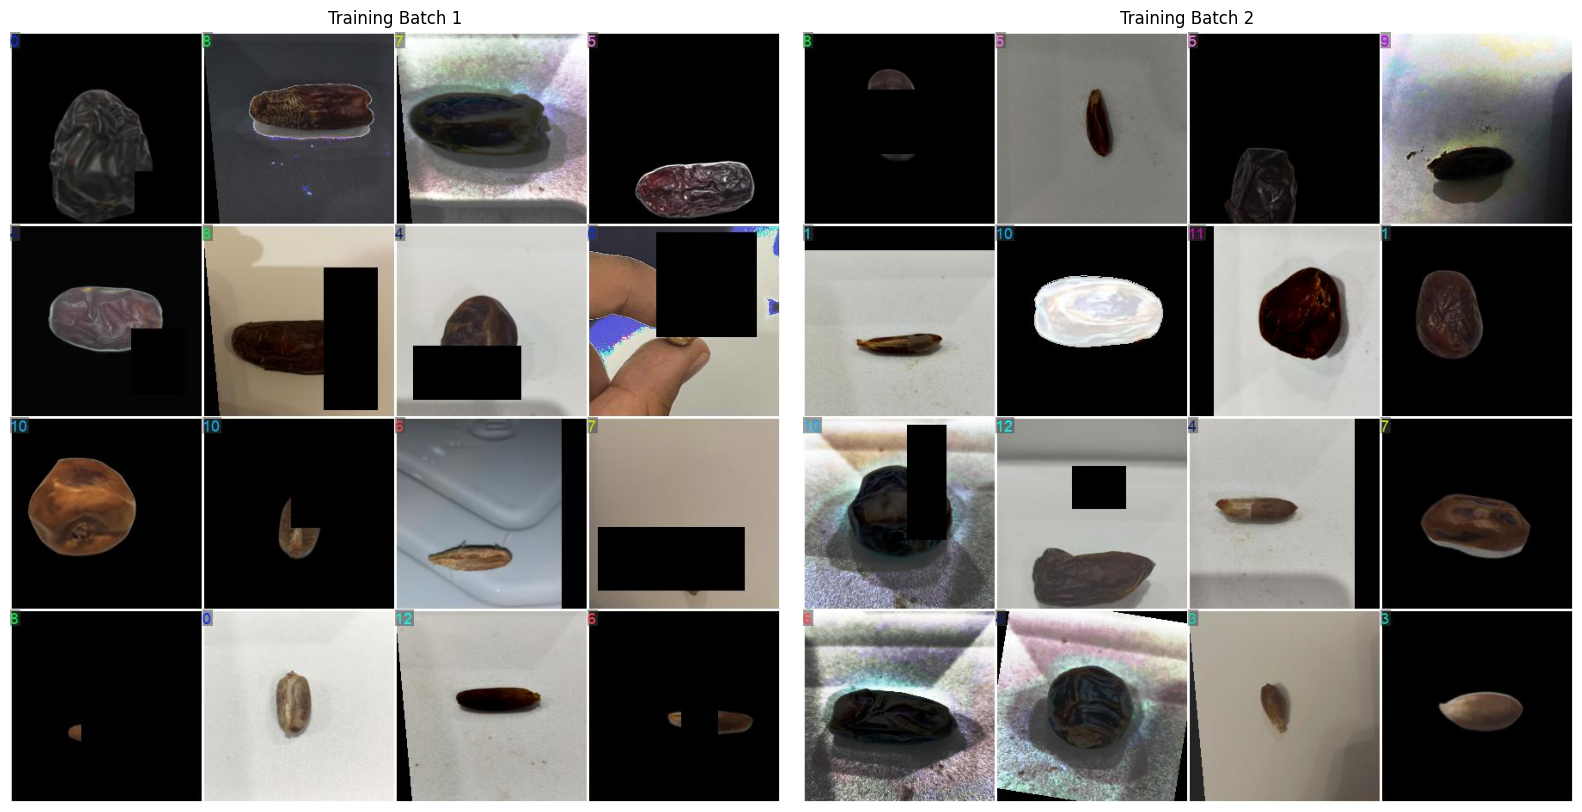

In [ ]:
# plot some of the training samples with their predicted labels and confidence scores
# use 2 images from (classify/date_classification/yolo_date_model/train_batch.jpg) to show the training images

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image 

#display the training batch image (2 images next to each other)
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
#display the training batch image
train_batch_imgs = ['classify/date_classification/yolo_date_model/train_batch1.jpg', 'classify/date_classification/yolo_date_model/train_batch2.jpg']
for i, img_path in enumerate(train_batch_imgs):
    img = Image.open(img_path)
    axs[i].imshow(img)
    axs[i].axis('off')
    axs[i].set_title(f'Training Batch {i+1}')
plt.tight_layout()
plt.show()

#### Validation samples

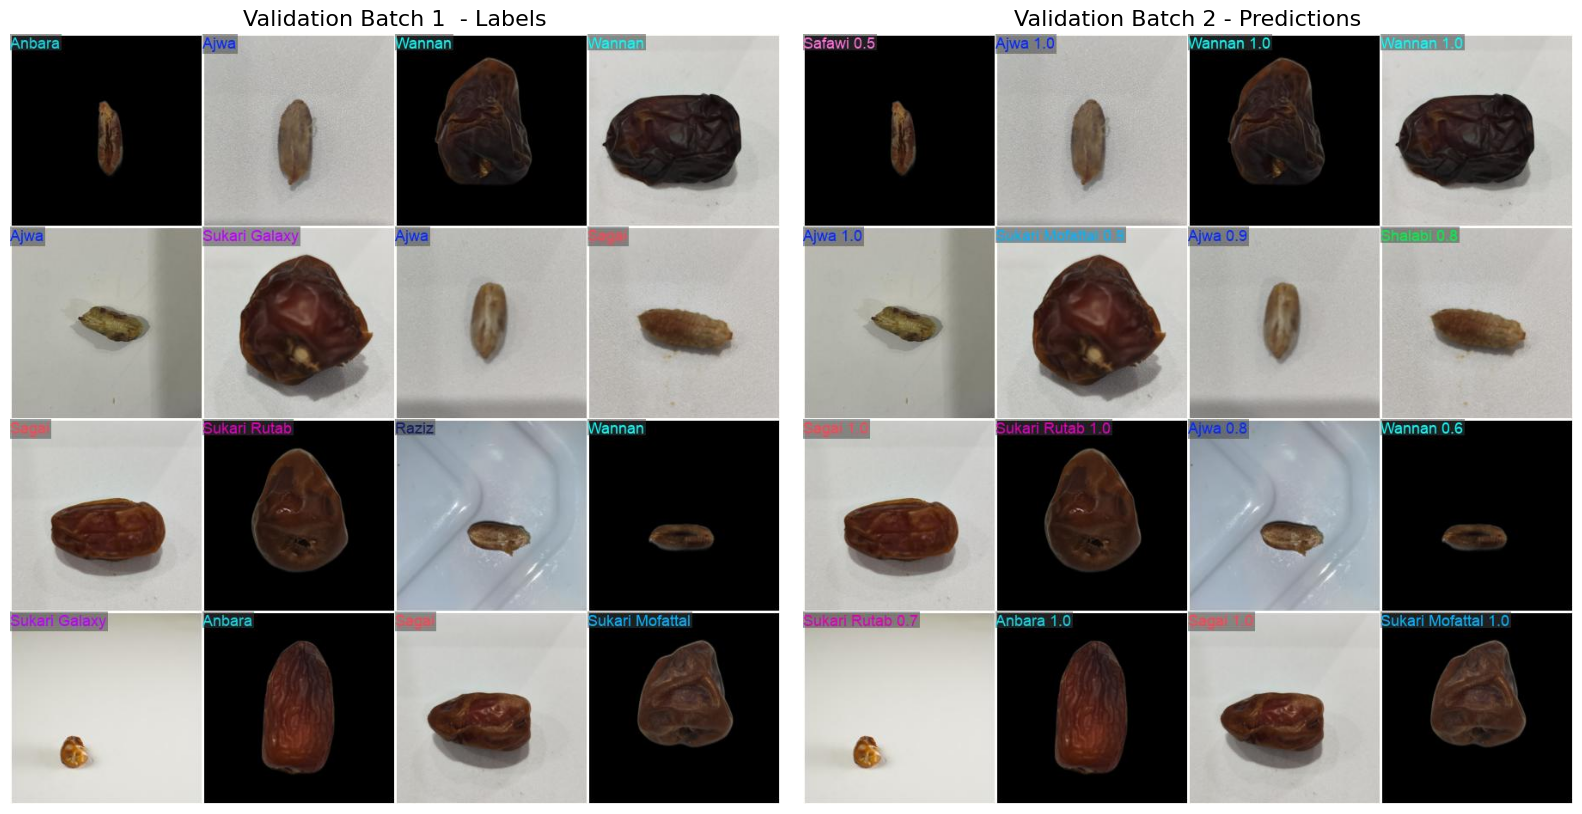

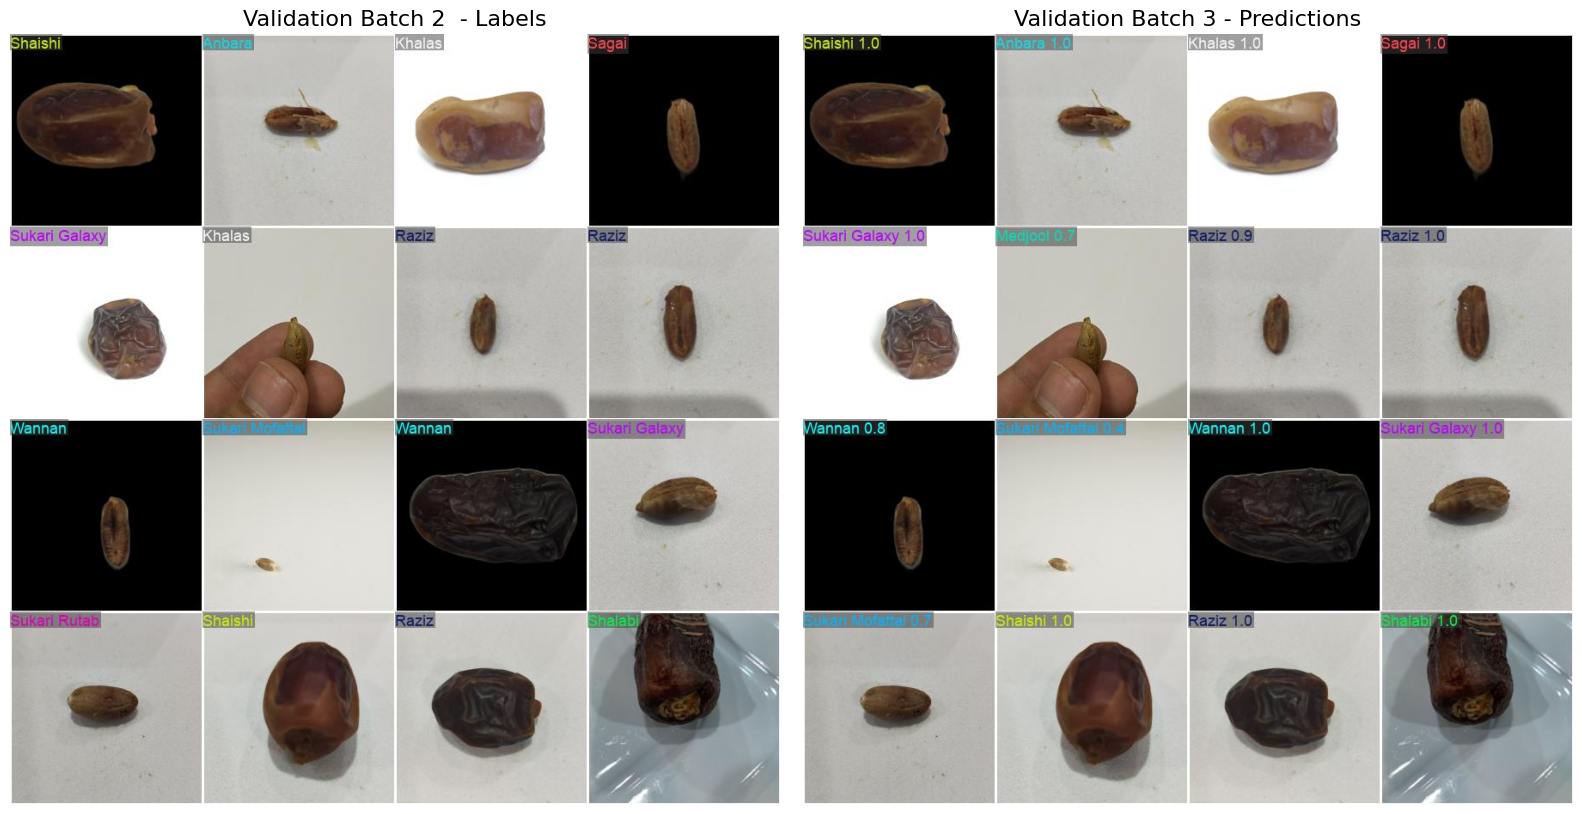

In [ ]:
# use (classify/date_classification/yolo_date_model/val_batch1_labels.jpg) and (classify/date_classification/yolo_date_model/val_batch1_pred.jpg) to show the validation images with their predicted labels and confidence scores
#display the validation batch images (2 images next to each other)

fig, axs = plt.subplots(1,2, figsize=(16, 8))
val_batch_imgs = ['classify/date_classification/yolo_date_model/val_batch1_labels.jpg' , 'classify/date_classification/yolo_date_model/val_batch1_pred.jpg']

for i, img_path in enumerate(val_batch_imgs):
    img = Image.open(img_path)
    axs[i].imshow(img)
    axs[i].axis('off')
    title = f'Validation Batch {i + 1}  - Labels' if i % 2 == 0 else f'Validation Batch {i + 1} - Predictions'
    axs[i].set_title(title, fontsize=16)
plt.tight_layout()
plt.show()

val_batch_imgs = ['classify/date_classification/yolo_date_model/val_batch2_labels.jpg' , 'classify/date_classification/yolo_date_model/val_batch2_pred.jpg']
#display the validation batch images (2 images next to each other)
fig, axs = plt.subplots(1,2, figsize=(16, 8))
for i, img_path in enumerate(val_batch_imgs):
    img = Image.open(img_path)
    axs[i].imshow(img)
    axs[i].axis('off')
    title = f'Validation Batch {i + 2}  - Labels' if i % 2 == 0 else f'Validation Batch {i + 2} - Predictions'
    axs[i].set_title(title, fontsize=16)
plt.tight_layout()
plt.show()

####  Losses and accracy Curves

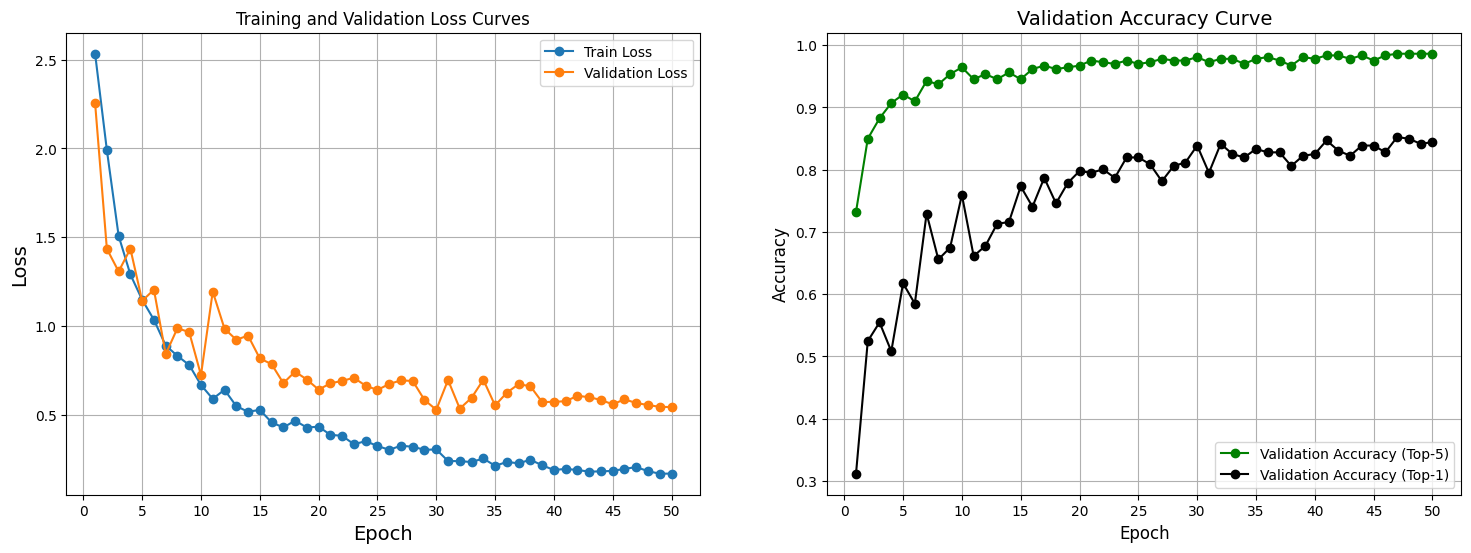

In [ ]:
# Losses and accracy Curves
# use the results.csv file to plot the training and validation loss curves and the accuracy curve
# then we will use it to get the confusion matrix and the classification report


results_df = pd.read_csv('classify/date_classification/yolo_date_model/results.csv')

#plot the training and validation loss curves and the accuracy curve across epochs
# train and validation loss curves together
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.plot(results_df['epoch'], results_df['train/loss'], label='Train Loss', marker='o')
plt.plot(results_df['epoch'], results_df['val/loss'], label='Validation Loss', marker='o')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid()

# --- CHANGE STEP SIZE TO 5 HERE ---
# np.arange(start, stop, step) -> from 0 to 50 with a step of 5
plt.xticks(np.arange(0, 51, 5))


# accuracy curves together (top-1 and top-5)
plt.subplot(1,2,2)
plt.plot(results_df['epoch'], results_df['metrics/accuracy_top5'],label='Validation Accuracy (Top-5)', marker='o',color='green')
plt.plot(results_df['epoch'], results_df['metrics/accuracy_top1'], label='Validation Accuracy (Top-1)', marker='o',color='black')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Validation Accuracy Curve', fontsize=14)
plt.legend()
plt.grid()


# Change stepsize: np.arange(start, stop, step) -> from 0 to 50 with a step of 5
plt.xticks(np.arange(0, 51, 5))

plt.show()

### Confusion Matrix & Performance Report

In [ ]:
# Performance Metrics
# After training, you can evaluate the model's performance using the validation set. Common metrics for classification include:
# - Accuracy: The percentage of correctly classified samples.
# - Precision: The ratio of true positives to the sum of true positives and false positives.
# - Recall: The ratio of true positives to the sum of true positives and false negatives.
# - F1 Score: The harmonic mean of precision and recall, providing a single metric that balances both.
# - Confusion Matrix: A table that summarizes the performance of a classification model by showing the true vs. predicted labels, allowing you to identify specific classes that are being misclassified.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load your trained model weights
model_path = 'classify/date_classification/yolo_date_model/weights/best.pt'
model = YOLO(model_path)

# 2. Path to validation directory
val_dir = Path('data/yolo_dataset/val')

# 3. Get the actual class names and map them to their index
# YOLO saves class names in model.names dictionary (e.g., {0: 'Ajwa', 1: 'Wannan', ...})
class_names = [model.names[i] for i in range(len(model.names))]

true_labels = []
pred_labels = []

print("Running inference on validation set to compute detailed metrics...")
# Loop through each class folder in the validation set
for class_idx, class_name in enumerate(class_names):
    class_folder = val_dir / class_name
    if not class_folder.exists():
        continue
        
    # Get all images in this class folder
    img_paths = list(class_folder.glob('*'))
    if not img_paths:
        continue
        
    # Run batch prediction on these images
    results = model.predict(source=img_paths, conf=0.0, verbose=False)
    
    for res in results:
        # Get the predicted class index (top-1)
        pred_idx = res.probs.top1
        
        true_labels.append(class_idx)
        pred_labels.append(pred_idx)

# 4. Generate Classification Report (Accuracy, Precision, Recall, F1)
print("\n" + "="*60)
print(' '* 18 ,"CLASSIFICATION REPORT", " " * 15)
print("="*60)
print(classification_report(true_labels, pred_labels, target_names=class_names))



Running inference on validation set to compute detailed metrics...

                   CLASSIFICATION REPORT                
                 precision    recall  f1-score   support

           Ajwa       0.90      0.96      0.93        28
         Anbara       0.93      0.89      0.91        28
         Khalas       0.84      0.72      0.78        29
        Medjool       0.96      0.89      0.93        28
          Raziz       0.77      0.86      0.81        28
         Safawi       0.90      0.90      0.90        29
          Sagai       0.88      0.79      0.83        28
        Shaishi       0.82      0.82      0.82        28
        Shalabi       0.93      0.93      0.93        28
  Sukari Galaxy       0.81      0.75      0.78        28
Sukari Mofattal       0.69      0.86      0.76        28
   Sukari Rutab       0.81      0.75      0.78        28
         Wannan       0.90      0.96      0.93        28

       accuracy                           0.85       366
      macro avg   

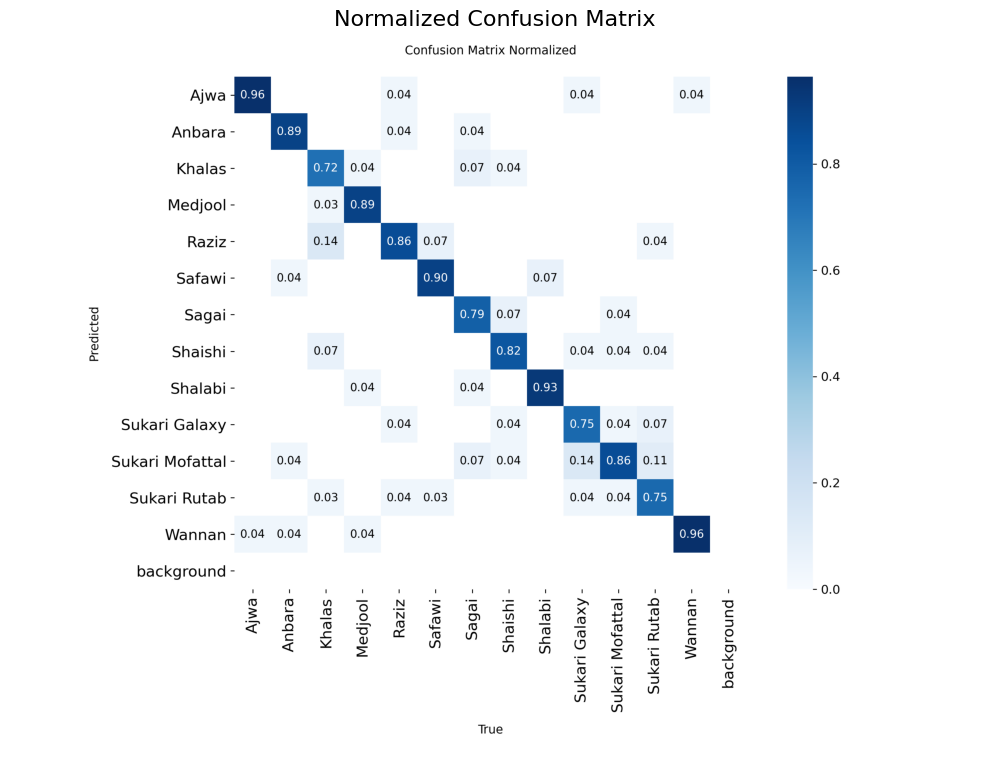

In [ ]:
# 5. plot the confusion matrix (normalized)
cm = Image.open('classify/date_classification/yolo_date_model/confusion_matrix_normalized.png')

#show the cm image using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(cm)
plt.axis('off')
plt.title('Normalized Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.show()

#### Run Infrence on the Test Dataset (unlabled) to test the model's result

In [ ]:
os.listdir('data/yolo_dataset/test')[:10]  # Display first 10 test images to verify they are correctly copied

['527.png',
 '583.png',
 '457.png',
 '430.jpg',
 '431.jpg',
 '631.png',
 '298.jpg',
 '79.png',
 '503.png',
 '197.jpg']

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from tqdm import tqdm

# 1. Load the trained model weights
model_path = 'classify/date_classification/yolo_date_model/weights/best.pt'
model = YOLO(model_path)

# 2. Get the list of all test images
test_folder = Path('data/yolo_dataset/test')
test_image_paths = list(test_folder.glob('*'))

print(f"Total test images found: {len(test_image_paths)}")

# 3. Dictionary to store the final numeric predictions
# Key will be the Image ID (int), and Value will be the Class Label (int)
predictions_dict = {}

# 4. Loop through each image one by one with a progress bar
print("Starting test dataset inference...")
for img_path in tqdm(test_image_paths, desc="Processing Images"):
    
    # Run prediction on the single image
    results = model.predict(source=str(img_path), conf=0.0, verbose=False)
    single_result = results[0]  # Get the result object for this image
    
    # A. Extract the Image ID from the filename (e.g., '527.png' -> '527')
    filename_str = single_result.path
    image_filename = Path(filename_str).stem  # This gives just the name '527'
    image_id_int = int(image_filename)        # Convert to integer to match CSV
    
    # B. Get the predicted class index (highest probability index)
    highest_prob_index = single_result.probs.top1
    
    # C. Convert the index to the English text name (e.g., 0 -> 'Ajwa')
    predicted_class_name = single_result.names[highest_prob_index]
    
    # D. Map the English name back to the Kaggle numeric ID (e.g., 'Ajwa' -> 1)
    # Using the 'label_to_class' dictionary we created earlier (reversed)
    numeric_class_label = 1  # Default fallback
    for num_id, name in label_to_class.items():
        if name == predicted_class_name:
            numeric_class_label = num_id
            break
            
    # E. Save the final result inside our predictions dictionary
    predictions_dict[image_id_int] = numeric_class_label

print("Inference completed successfully!")


# 5. Save results into the Kaggle CSV format
print("Structuring submission file...")
test_df_final = pd.read_csv('data/soda_dataset/test.csv')

# Map the predictions dictionary to the 'id' column in the CSV dataframe
test_df_final['label'] = test_df_final['id'].map(predictions_dict)

# Save the final DataFrame to a new CSV file
submission_file_path = 'final_kaggle_submission.csv'

Total test images found: 784
Starting test dataset inference...


Processing Images: 100%|██████████| 784/784 [01:22<00:00,  9.48it/s]

Inference completed successfully!
Structuring submission file...


Plotting 4 random test predictions...


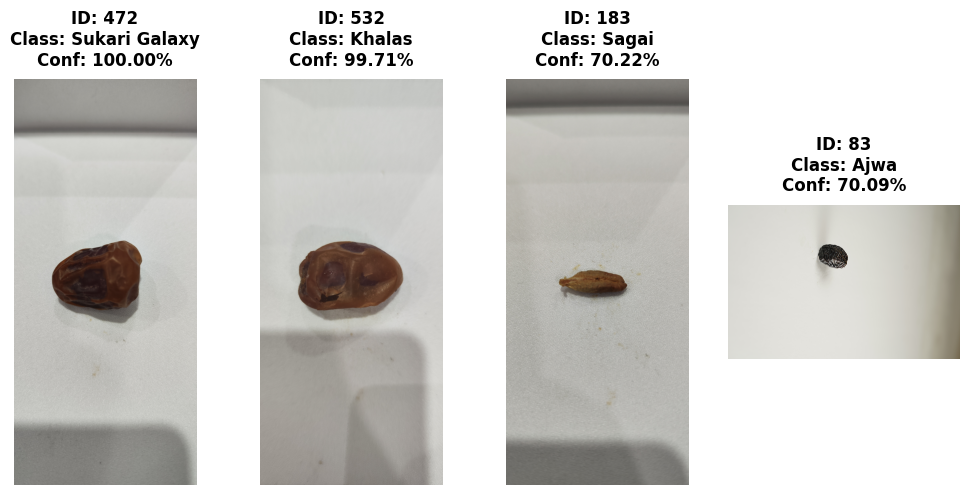

In [ ]:
import random
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# 1. Load the model weights
model_path = 'classify/date_classification/yolo_date_model/weights/best.pt'
model = YOLO(model_path)

# 2. Get all image paths from the test folder
test_folder = Path('data/yolo_dataset/test')
all_test_images = list(test_folder.glob('*'))

# 3. Pick exactly 4 RANDOM images from the list
random_sample_paths = random.sample(all_test_images, 4)

# 4. Setup a clean grid with 1 row and 4 columns
fig, axes = plt.subplots(1, 4, figsize=(10, 5))

print("Plotting 4 random test predictions...")

for i in range(4):
    img_path = random_sample_paths[i]
    
    # Run prediction on the single image
    res = model.predict(source=str(img_path), conf=0.0, verbose=False)[0]
    
    # Extract prediction details
    pred_class_name = res.names[res.probs.top1]
    confidence_score = res.probs.top1conf.item() * 100
    image_id = img_path.stem
    
    # Read and display the image matrix
    img_matrix = plt.imread(img_path)
    axes[i].imshow(img_matrix)
    axes[i].axis('off')  # Hide the pixel grid completely
    
    # Display the results as normal plain text on top of each image
    normal_text_title = f"ID: {image_id}\nClass: {pred_class_name}\nConf: {confidence_score:.2f}%"
    axes[i].set_title(normal_text_title, fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()